# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns
from scipy import stats

np.random.seed(42)

## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

In [70]:
# your code here
from scipy.stats import uniform

# Example: 10 numbers between 10 and 15 (loc = start, scale = width)
uniform.rvs(loc=10, scale=5, size=10)

array([11.87270059, 14.75357153, 13.65996971, 12.99329242, 10.7800932 ,
       10.7799726 , 10.29041806, 14.33088073, 13.00557506, 13.54036289])

**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

In [71]:
# your code here
def uniform_numbers(bottom, ceiling, count):
    return uniform.rvs(loc=bottom, scale=ceiling - bottom, size=count)

In [72]:
# your code here
uniform_1 = uniform_numbers(10, 15, 100)
uniform_2 = uniform_numbers(10, 60, 1000)

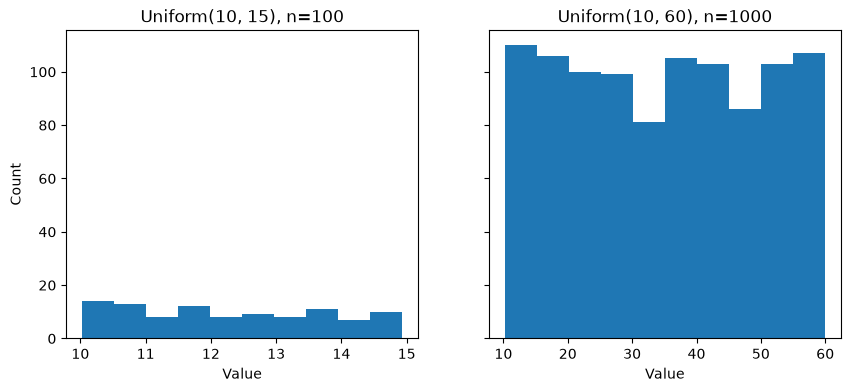

In [73]:
# your code here
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].hist(uniform_1, bins=10)
axes[0].set(title="Uniform(10, 15), n=100", xlabel="Value", ylabel="Count")
axes[1].hist(uniform_2, bins=10)
axes[1].set(title="Uniform(10, 60), n=1000", xlabel="Value")
plt.show()

How are the two distributions different?

Both are flat, because every value in the range is equally likely. The first covers 10–15 and the second covers 10–60, so the mean moves from 12.5 to 35 and the spread is 10 times larger. The first has only 100 values, about 10 per bin, so its bars are low and noisier. The second has about 100 per bin and looks closer to perfectly flat.

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

In [74]:
from scipy.stats import norm 

In [75]:
# your code here
def normal_numbers(mean, std, count):
    return norm.rvs(loc=mean, scale=std, size=count)

In [76]:
# your code here
normal_1 = normal_numbers(10, 1, 1000)
normal_2 = normal_numbers(10, 50, 1000)

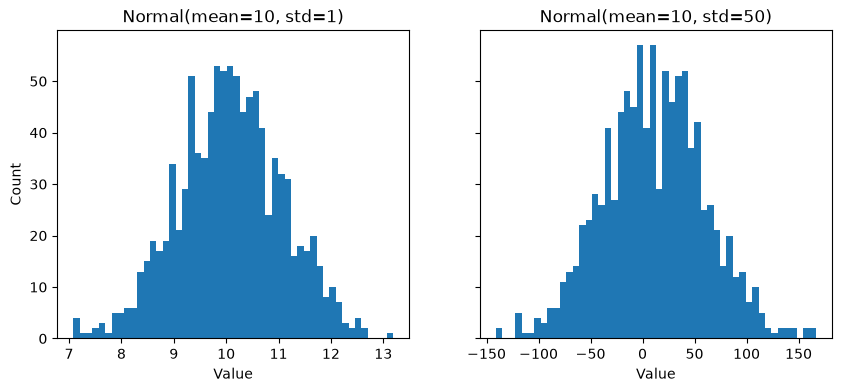

In [77]:
# your code here
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].hist(normal_1, bins=50)
axes[0].set(title="Normal(mean=10, std=1)", xlabel="Value", ylabel="Count")
axes[1].hist(normal_2, bins=50)
axes[1].set(title="Normal(mean=10, std=50)", xlabel="Value")
plt.show()

In [78]:
# your code here

How are the two distributions different?

They have the same centre (10) and the same bell shape. Only the spread changes: with σ=1 the values fall roughly between 7 and 13, and with σ=50 between about −140 and 160. The plots look alike because matplotlib rescales the x-axis automatically, so the axis labels are what reveal the difference.

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [79]:
# your code here
vehicles = pd.read_csv("vehicles.csv")
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

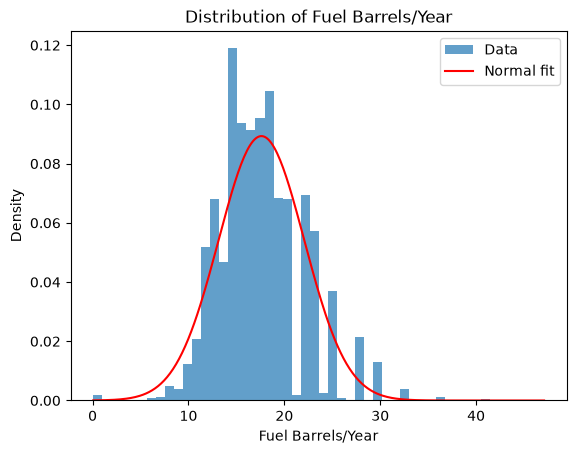

In [80]:
# your code here
def plot_with_normal(column, bins=50):
    data = vehicles[column]
    plt.hist(data, bins=bins, density=True, alpha=0.7, label="Data")
    x = np.linspace(data.min(), data.max(), 300)
    plt.plot(x, stats.norm.pdf(x, data.mean(), data.std()), "r-", label="Normal fit")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

plot_with_normal("Fuel Barrels/Year")

In [81]:
# your code here
col = vehicles["Fuel Barrels/Year"]
print(f"mean {col.mean():.2f} | median {col.median():.2f} | skew {col.skew():.2f}")

mean 17.61 | median 17.35 | skew 0.64


2. CO2 Emission Grams/Mile 

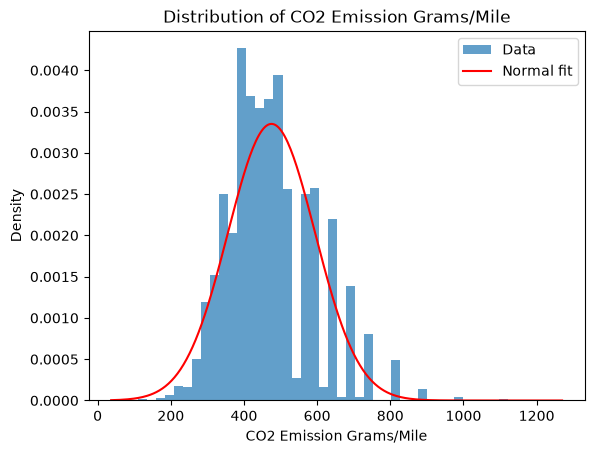

In [82]:
# your code here
plot_with_normal("CO2 Emission Grams/Mile")

In [83]:
# your code here
col = vehicles["CO2 Emission Grams/Mile"]
print(f"mean {col.mean():.2f} | median {col.median():.2f} | skew {col.skew():.2f}")

mean 475.32 | median 467.74 | skew 0.74


3. Combined MPG

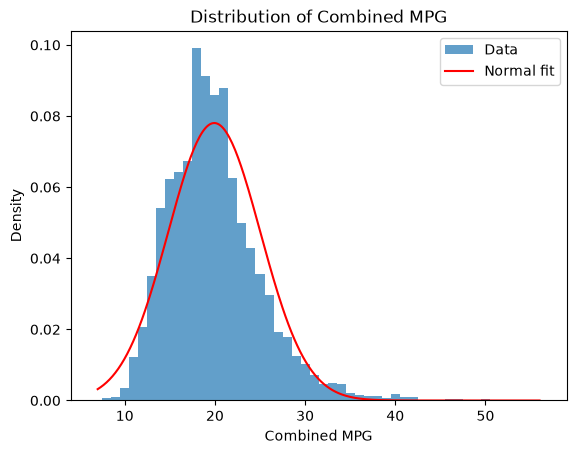

In [84]:
# your code here
plot_with_normal("Combined MPG", bins=np.arange(7, 58) - 0.5)

In [85]:
# your code here
col = vehicles["Combined MPG"]
print(f"mean {col.mean():.2f} | median {col.median():.2f} | skew {col.skew():.2f}")

mean 19.93 | median 19.00 | skew 1.07


In [86]:
# your code here
vehicles[["Fuel Barrels/Year", "CO2 Emission Grams/Mile", "Combined MPG"]].corr()

,Fuel Barrels/Year,CO2 Emission Grams/Mile,Combined MPG
Fuel Barrels/Year,1.000000,0.986189,-0.909743
CO2 Emission Grams/Mile,0.986189,1.000000,-0.926229
Combined MPG,-0.909743,-0.926229,1.000000


Which one(s) of the variables are nearly normally distributed? How do you know?

In [87]:
# your code here
cols = ["Fuel Barrels/Year", "CO2 Emission Grams/Mile", "Combined MPG"]
vehicles[cols].skew()

Fuel Barrels/Year          0.638271
CO2 Emission Grams/Mile    0.741692
Combined MPG               1.067773
dtype: float64

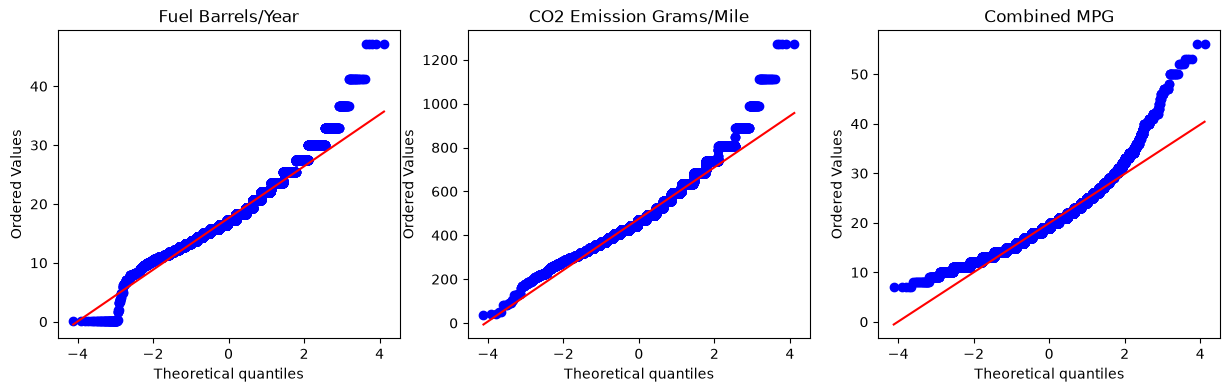

In [88]:
# your code here
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, cols):
    stats.probplot(vehicles[c], dist="norm", plot=ax)
    ax.set_title(c)
plt.show()

In [89]:
# your code here

In [90]:
# your code here

Strictly, none of them is normal (all are right-skewed).
Fuel Barrels/Year (skew 0.64) and CO2 Emission (skew 0.74) are NEARLY normal:
bell-shaped, mean close to median, QQ plot only bends in the right tail.
Combined MPG (skew 1.07) is NOT: long right tail, QQ plot curves strongly upwards.

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

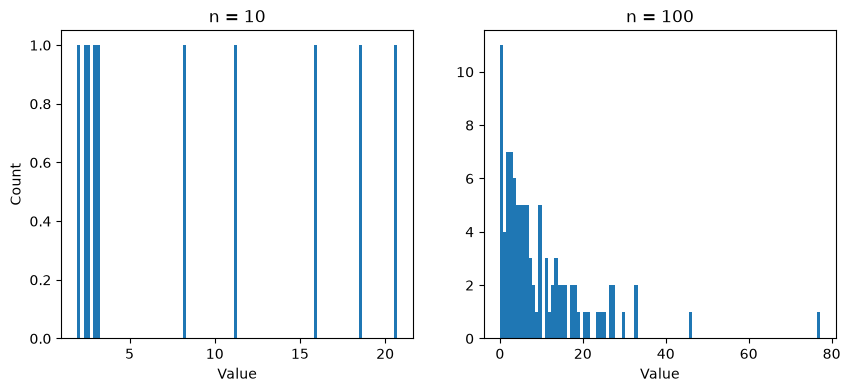

In [91]:
# your code here
def exponential_numbers(mean, size):
    return np.random.exponential(scale=mean, size=size)

exp_10 = exponential_numbers(10, 10)
exp_100 = exponential_numbers(10, 100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(exp_10, bins=100)
axes[0].set(title="n = 10", xlabel="Value", ylabel="Count")
axes[1].hist(exp_100, bins=100)
axes[1].set(title="n = 100", xlabel="Value")
plt.show()

How are the two distributions different?

The mean does NOT change: both samples have mean 10. Only the sample size differs.
With 10 values the shape is unrecognisable; with 100 the exponential decay appears.

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

In [92]:
# your code here
lam = 1 / 10

In [93]:
# your answer here
# Hint: This is same as saying P(x<15)
p_less_15 = 1 - math.exp(-lam * 15)
print(round(p_less_15, 3))   # 0.777

0.777


What is the probability that the customer will spend more than 15 minutes

In [94]:
# your code here
p_more_15 = 1 - p_less_15
print(round(p_more_15, 3))   # 0.223

0.223
